# 03 - Preprocessing & Augmentation


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os, json
import numpy as np
import pandas as pd
from pathlib import Path

BASE_DIR    = '/content/drive/MyDrive/leaf_disease_project'
PROC_DIR    = os.path.join(BASE_DIR, 'data', 'processed')
RESULTS_DIR = os.path.join(BASE_DIR, 'results')

with open(os.path.join(PROC_DIR, 'config.json'), 'r') as f:
    config = json.load(f)

with open(os.path.join(PROC_DIR, 'class_manifest.json'), 'r') as f:
    manifest = json.load(f)

with open(os.path.join(PROC_DIR, 'dataset_stats.json'), 'r') as f:
    stats = json.load(f)

manifest_df = pd.DataFrame(manifest)
color_dir   = Path(config['color_dir'])
N_CLASSES   = config['n_classes']
IMG_SIZE    = config['img_size']
MEAN_RGB    = stats['mean_rgb']
STD_RGB     = stats['std_rgb']

print(f'Config loaded.')
print(f'  Classes  : {N_CLASSES}')
print(f'  Img size : {IMG_SIZE}x{IMG_SIZE}')
print(f'  Mean RGB : {[round(v,4) for v in MEAN_RGB]}')
print(f'  Std  RGB : {[round(v,4) for v in STD_RGB]}')

Config loaded.
  Classes  : 38
  Img size : 224x224
  Mean RGB : [0.4655, 0.4885, 0.4113]
  Std  RGB : [0.1723, 0.1456, 0.1889]


In [3]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.model_selection import train_test_split
from tqdm import tqdm

print(f'PyTorch version : {torch.__version__}')
print(f'CUDA available  : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU             : {torch.cuda.get_device_name(0)}')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

PyTorch version : 2.10.0+cu128
CUDA available  : True
GPU             : Tesla T4


In [4]:
print('Building image index...')

all_samples = []  # list of (path, class_idx)

for _, row in tqdm(manifest_df.iterrows(), total=len(manifest_df)):
    folder    = Path(row['path'])
    class_idx = row['class_idx']
    images    = (list(folder.glob('*.jpg')) +
                 list(folder.glob('*.JPG')) +
                 list(folder.glob('*.png')))
    for img_path in images:
        all_samples.append((str(img_path), class_idx))

all_samples = np.array(all_samples, dtype=object)
all_paths   = all_samples[:, 0]
all_labels  = all_samples[:, 1].astype(int)

print(f'Total samples indexed : {len(all_samples):,}')
print(f'Classes               : {len(np.unique(all_labels))}')

Building image index...


100%|██████████| 38/38 [00:50<00:00,  1.32s/it]

Total samples indexed : 54,304
Classes               : 38


In [5]:
TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15
TEST_RATIO  = 0.15
SEED        = 42

indices = np.arange(len(all_samples))

# First split: train vs (val + test)
train_idx, temp_idx = train_test_split(
    indices,
    test_size=(VAL_RATIO + TEST_RATIO),
    stratify=all_labels,
    random_state=SEED
)

# Second split: val vs test
val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=TEST_RATIO / (VAL_RATIO + TEST_RATIO),
    stratify=all_labels[temp_idx],
    random_state=SEED
)

print(f'Split summary (seed={SEED}):')
print(f'  Train : {len(train_idx):,}  ({100*len(train_idx)/len(indices):.1f}%)')
print(f'  Val   : {len(val_idx):,}   ({100*len(val_idx)/len(indices):.1f}%)')
print(f'  Test  : {len(test_idx):,}   ({100*len(test_idx)/len(indices):.1f}%)')
print(f'  Total : {len(train_idx)+len(val_idx)+len(test_idx):,}')

Split summary (seed=42):
  Train : 38,012  (70.0%)
  Val   : 8,146   (15.0%)
  Test  : 8,146   (15.0%)
  Total : 54,304


In [6]:
# Verify stratification — check class distribution is similar across splits
def class_dist(idx):
    labels = all_labels[idx]
    counts = np.bincount(labels, minlength=N_CLASSES)
    return counts / counts.sum()

train_dist = class_dist(train_idx)
val_dist   = class_dist(val_idx)
test_dist  = class_dist(test_idx)

max_drift = np.abs(train_dist - test_dist).max()
print(f'Max class proportion drift (train vs test): {max_drift:.4f}')
print('Stratification looks good.' if max_drift < 0.01 else 'WARNING: high drift, check split.')

Max class proportion drift (train vs test): 0.0001
Stratification looks good.


In [7]:
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.RandomRotation(degrees=30),
    transforms.ColorJitter(
        brightness=0.3,
        contrast=0.3,
        saturation=0.3,
        hue=0.1
    ),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN_RGB, std=STD_RGB),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.1)),
])

eval_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN_RGB, std=STD_RGB),
])

print('Transform pipelines defined.')
print()
print('Train transforms:')
for t in train_transforms.transforms:
    print(f'  {t.__class__.__name__}')
print()
print('Eval transforms:')
for t in eval_transforms.transforms:
    print(f'  {t.__class__.__name__}')

Transform pipelines defined.

Train transforms:
  Resize
  RandomHorizontalFlip
  RandomVerticalFlip
  RandomRotation
  ColorJitter
  RandomAffine
  ToTensor
  Normalize
  RandomErasing

Eval transforms:
  Resize
  ToTensor
  Normalize


In [8]:
class LeafDiseaseDataset(Dataset):
    """
    PyTorch Dataset for PlantVillage leaf disease images.

    Args:
        paths     : array of image file paths
        labels    : array of integer class labels
        transform : torchvision transform pipeline
    """
    def __init__(self, paths, labels, transform=None):
        self.paths     = paths
        self.labels    = labels
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, self.labels[idx]


# Build full dataset (no transform — used for index splitting only)
full_dataset = LeafDiseaseDataset(all_paths, all_labels, transform=None)
print(f'Full dataset size: {len(full_dataset):,}')

Full dataset size: 54,304


In [9]:
def get_dataloaders(batch_size=32, num_workers=2):
    """
    Returns train, val, and test DataLoaders using the saved split indices.

    Args:
        batch_size  : images per batch
        num_workers : parallel workers for data loading

    Returns:
        train_loader, val_loader, test_loader
    """
    train_dataset = LeafDiseaseDataset(
        all_paths[train_idx], all_labels[train_idx], transform=train_transforms)
    val_dataset   = LeafDiseaseDataset(
        all_paths[val_idx],   all_labels[val_idx],   transform=eval_transforms)
    test_dataset  = LeafDiseaseDataset(
        all_paths[test_idx],  all_labels[test_idx],  transform=eval_transforms)

    train_loader = DataLoader(
        train_dataset, batch_size=batch_size,
        shuffle=True,  num_workers=num_workers, pin_memory=True)
    val_loader   = DataLoader(
        val_dataset,   batch_size=batch_size,
        shuffle=False, num_workers=num_workers, pin_memory=True)
    test_loader  = DataLoader(
        test_dataset,  batch_size=batch_size,
        shuffle=False, num_workers=num_workers, pin_memory=True)

    return train_loader, val_loader, test_loader


# Quick test
train_loader, val_loader, test_loader = get_dataloaders(batch_size=32)
print(f'Train batches : {len(train_loader)}')
print(f'Val   batches : {len(val_loader)}')
print(f'Test  batches : {len(test_loader)}')

# Check one batch
imgs, labels = next(iter(train_loader))
print(f'\nBatch shape : {imgs.shape}   dtype={imgs.dtype}')
print(f'Labels shape: {labels.shape}  range=[{labels.min()},{labels.max()}]')

Train batches : 1188
Val   batches : 255
Test  batches : 255

Batch shape : torch.Size([32, 3, 224, 224])   dtype=torch.float32
Labels shape: torch.Size([32])  range=[1,36]


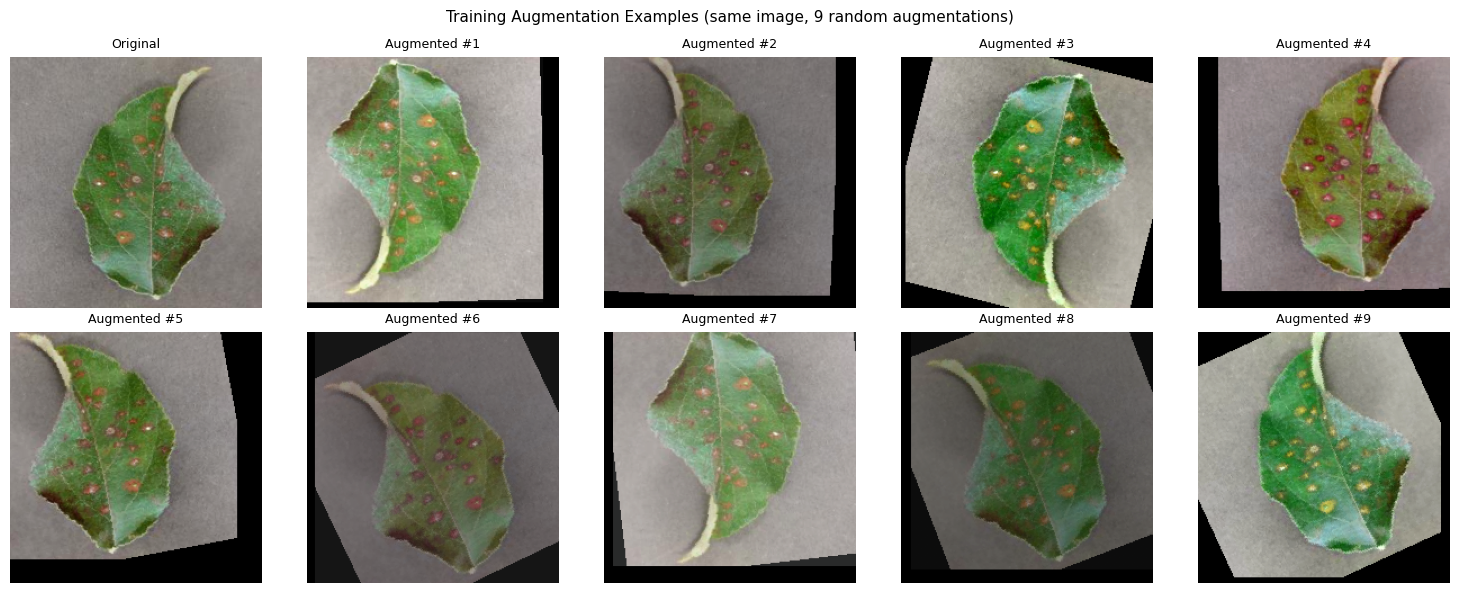

In [10]:
def denormalize(tensor, mean=MEAN_RGB, std=STD_RGB):
    """Reverse normalization for visualization."""
    t = tensor.clone()
    for c, (m, s) in enumerate(zip(mean, std)):
        t[c] = t[c] * s + m
    return torch.clamp(t, 0, 1)


# Pick one image from training set
sample_path = all_paths[train_idx[0]]
sample_img  = Image.open(sample_path).convert('RGB')

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

# Original
axes[0].imshow(sample_img.resize((IMG_SIZE, IMG_SIZE)))
axes[0].set_title('Original', fontsize=9)
axes[0].axis('off')

# 9 augmented versions
for i in range(1, 10):
    aug_tensor = train_transforms(sample_img)
    aug_img    = denormalize(aug_tensor).permute(1, 2, 0).numpy()
    axes[i].imshow(aug_img)
    axes[i].set_title(f'Augmented #{i}', fontsize=9)
    axes[i].axis('off')

plt.suptitle('Training Augmentation Examples (same image, 9 random augmentations)', fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, '03_augmentation_examples.png'), dpi=150)
plt.show()

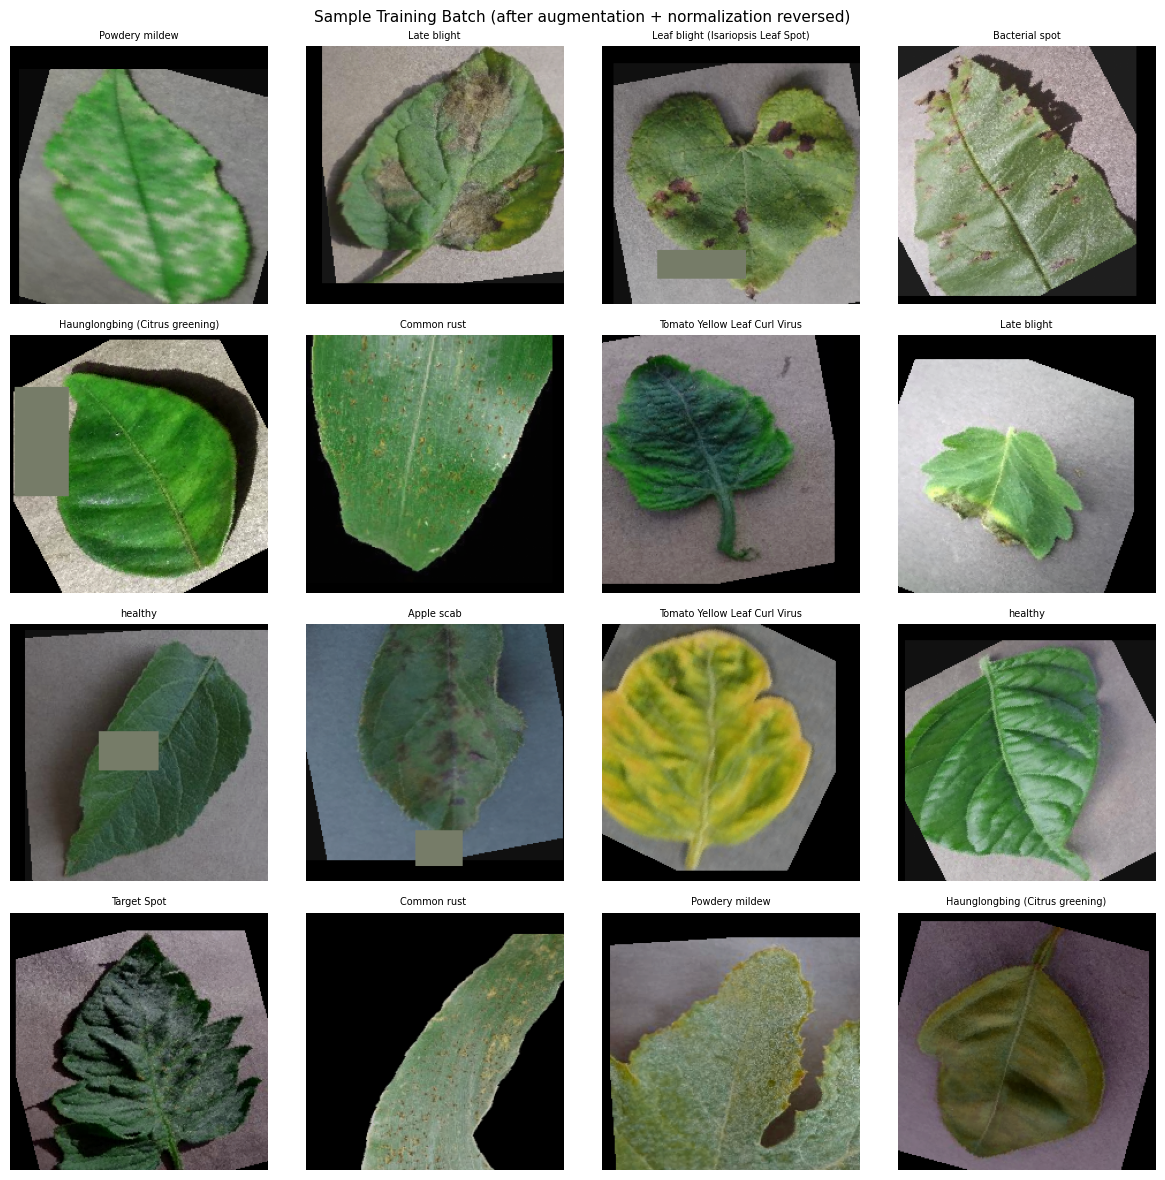

In [11]:
imgs, labels = next(iter(train_loader))

n_show = 16
fig, axes = plt.subplots(4, 4, figsize=(12, 12))
axes = axes.flatten()

idx_to_classname = {row['class_idx']: row['disease']
                    for _, row in manifest_df.iterrows()}

for i in range(n_show):
    img = denormalize(imgs[i]).permute(1, 2, 0).numpy()
    axes[i].imshow(img)
    axes[i].set_title(idx_to_classname.get(int(labels[i]), '?'), fontsize=7)
    axes[i].axis('off')

plt.suptitle('Sample Training Batch (after augmentation + normalization reversed)', fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, '03_sample_batch.png'), dpi=150)
plt.show()

In [12]:
train_labels  = all_labels[train_idx]
class_counts  = np.bincount(train_labels, minlength=N_CLASSES).astype(float)
class_weights = class_counts.sum() / (N_CLASSES * class_counts)
class_weights[class_counts == 0] = 0.0

print('Class weights (inverse frequency, training set):')
for i, (w, c) in enumerate(zip(class_weights, class_counts)):
    name = manifest_df.loc[manifest_df['class_idx'] == i, 'class_name'].values[0]
    print(f'  [{i:02d}] {name:<45}  count={int(c):>5}  weight={w:.3f}')

# Save
weights_path = os.path.join(PROC_DIR, 'class_weights.npy')
np.save(weights_path, class_weights)
print(f'\nSaved to: {weights_path}')

Class weights (inverse frequency, training set):
  [00] Apple - Apple scab                             count=  441  weight=2.268
  [01] Apple - Black rot                              count=  435  weight=2.300
  [02] Apple - Cedar apple rust                       count=  193  weight=5.183
  [03] Apple - healthy                                count= 1151  weight=0.869
  [04] Blueberry - healthy                            count= 1051  weight=0.952
  [05] Cherry (including sour) - Powdery mildew       count=  736  weight=1.359
  [06] Cherry (including sour) - healthy              count=  598  weight=1.673
  [07] Corn (maize) - Cercospora leaf spot Gray leaf spot  count=  359  weight=2.786
  [08] Corn (maize) - Common rust                     count=  834  weight=1.199
  [09] Corn (maize) - Northern Leaf Blight            count=  690  weight=1.450
  [10] Corn (maize) - healthy                         count=  813  weight=1.230
  [11] Grape - Black rot                              count=  826 

In [13]:
np.save(os.path.join(PROC_DIR, 'train_idx.npy'), train_idx)
np.save(os.path.join(PROC_DIR, 'val_idx.npy'),   val_idx)
np.save(os.path.join(PROC_DIR, 'test_idx.npy'),  test_idx)
np.save(os.path.join(PROC_DIR, 'all_paths.npy'), all_paths)
np.save(os.path.join(PROC_DIR, 'all_labels.npy'), all_labels)

print('Split indices saved:')
print(f'  train_idx.npy   : {len(train_idx):,} samples')
print(f'  val_idx.npy     : {len(val_idx):,} samples')
print(f'  test_idx.npy    : {len(test_idx):,} samples')
print(f'  all_paths.npy   : {len(all_paths):,} paths')
print(f'  all_labels.npy  : {len(all_labels):,} labels')

Split indices saved:
  train_idx.npy   : 38,012 samples
  val_idx.npy     : 8,146 samples
  test_idx.npy    : 8,146 samples
  all_paths.npy   : 54,304 paths
  all_labels.npy  : 54,304 labels
